In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

df = pd.read_csv('../data/raw/superstore.csv', encoding='latin-1')
print(df.shape)
print(df.head())

(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID 

In [5]:
print("COLUMN NAMES:")
print(df.columns.tolist())

print("\nDATA TYPES:")
print(df.dtypes)

print("\nNULL VALUES:")
print(df.isnull().sum())

print("\nBASIC STATS:")
print(df.describe())

COLUMN NAMES:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

DATA TYPES:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

NULL VALUES:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country 

In [6]:
# fix dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# engineer key columns
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')
df['Year-Month'] = df['Order Date'].dt.to_period('M').astype(str)

# flag negative profit rows
df['Is Loss'] = df['Profit'] < 0

print("New columns added:")
print(df[['Order Date', 'Days to Ship', 'Profit Margin %', 'Order Year', 'Year-Month', 'Is Loss']].head(10))
print(f"\nDate range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Years in dataset: {sorted(df['Order Year'].unique())}")
print(f"Avg days to ship: {df['Days to Ship'].mean():.1f}")
print(f"Loss-making orders: {df['Is Loss'].sum()} ({df['Is Loss'].mean()*100:.1f}%)")

New columns added:
  Order Date  Days to Ship  Profit Margin %  Order Year Year-Month  Is Loss
0 2016-11-08             3            16.00        2016    2016-11    False
1 2016-11-08             3            30.00        2016    2016-11    False
2 2016-06-12             4            47.00        2016    2016-06    False
3 2015-10-11             7           -40.00        2015    2015-10     True
4 2015-10-11             7            11.25        2015    2015-10    False
5 2014-06-09             5            29.00        2014    2014-06    False
6 2014-06-09             5            27.00        2014    2014-06    False
7 2014-06-09             5            10.00        2014    2014-06    False
8 2014-06-09             5            31.25        2014    2014-06    False
9 2014-06-09             5            30.00        2014    2014-06    False

Date range: 2014-01-03 to 2017-12-30
Years in dataset: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Avg days to ship: 4.0
Lo

In [7]:
print("=== EXECUTIVE KPIs ===")
print(f"Total Revenue:       ${df['Sales'].sum():,.0f}")
print(f"Total Profit:        ${df['Profit'].sum():,.0f}")
print(f"Overall Margin:      {(df['Profit'].sum()/df['Sales'].sum()*100):.1f}%")
print(f"Total Orders:        {df['Order ID'].nunique():,}")
print(f"Total Customers:     {df['Customer ID'].nunique():,}")
print(f"Avg Order Value:     ${df.groupby('Order ID')['Sales'].sum().mean():,.0f}")
print(f"Avg Days to Ship:    {df['Days to Ship'].mean():.1f} days")

print("\n=== REVENUE BY REGION ===")
print(df.groupby('Region')[['Sales','Profit']].sum().round(0).sort_values('Sales', ascending=False))

print("\n=== REVENUE BY CATEGORY ===")
print(df.groupby('Category')[['Sales','Profit']].sum().round(0).sort_values('Sales', ascending=False))

print("\n=== REVENUE BY SEGMENT ===")
print(df.groupby('Segment')[['Sales','Profit']].sum().round(0).sort_values('Sales', ascending=False))

=== EXECUTIVE KPIs ===
Total Revenue:       $2,297,201
Total Profit:        $286,397
Overall Margin:      12.5%
Total Orders:        5,009
Total Customers:     793
Avg Order Value:     $459
Avg Days to Ship:    4.0 days

=== REVENUE BY REGION ===
            Sales    Profit
Region                     
West    725458.00 108418.00
East    678781.00  91523.00
Central 501240.00  39706.00
South   391722.00  46749.00

=== REVENUE BY CATEGORY ===
                    Sales    Profit
Category                           
Technology      836154.00 145455.00
Furniture       742000.00  18451.00
Office Supplies 719047.00 122491.00

=== REVENUE BY SEGMENT ===
                 Sales    Profit
Segment                         
Consumer    1161401.00 134119.00
Corporate    706146.00  91979.00
Home Office  429653.00  60299.00


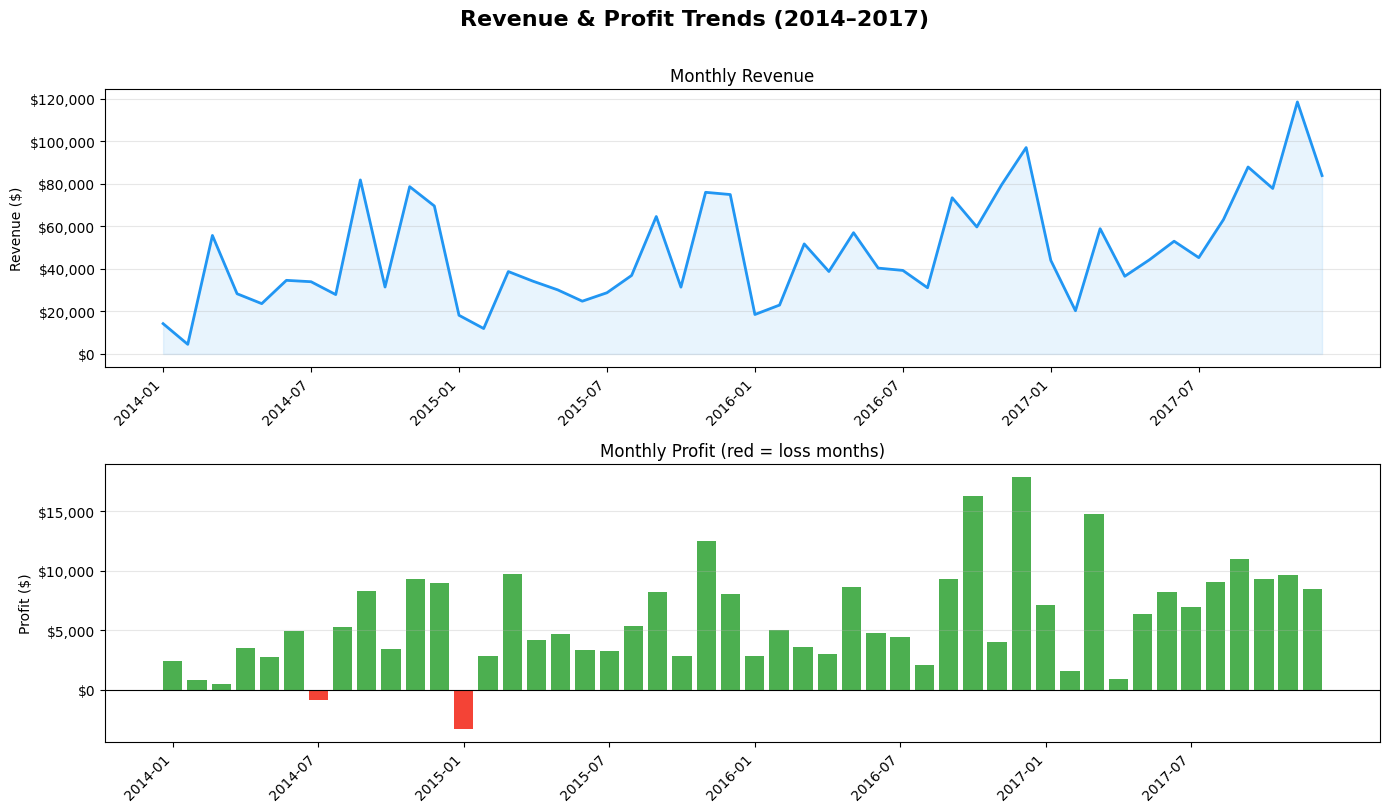

Saved.


In [8]:
monthly = df.groupby('Year-Month')[['Sales','Profit']].sum().reset_index()
monthly = monthly.sort_values('Year-Month')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Revenue & Profit Trends (2014–2017)', fontsize=16, fontweight='bold', y=1.01)

ax1.plot(monthly['Year-Month'], monthly['Sales'], color='#2196F3', linewidth=2)
ax1.fill_between(range(len(monthly)), monthly['Sales'], alpha=0.1, color='#2196F3')
ax1.set_xticks(range(0, len(monthly), 6))
ax1.set_xticklabels(monthly['Year-Month'].iloc[::6], rotation=45, ha='right')
ax1.set_ylabel('Revenue ($)')
ax1.set_title('Monthly Revenue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(axis='y', alpha=0.3)

ax2.bar(range(len(monthly)), monthly['Profit'],
        color=['#4CAF50' if x > 0 else '#f44336' for x in monthly['Profit']])
ax2.set_xticks(range(0, len(monthly), 6))
ax2.set_xticklabels(monthly['Year-Month'].iloc[::6], rotation=45, ha='right')
ax2.set_ylabel('Profit ($)')
ax2.set_title('Monthly Profit (red = loss months)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../outputs/01_revenue_profit_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

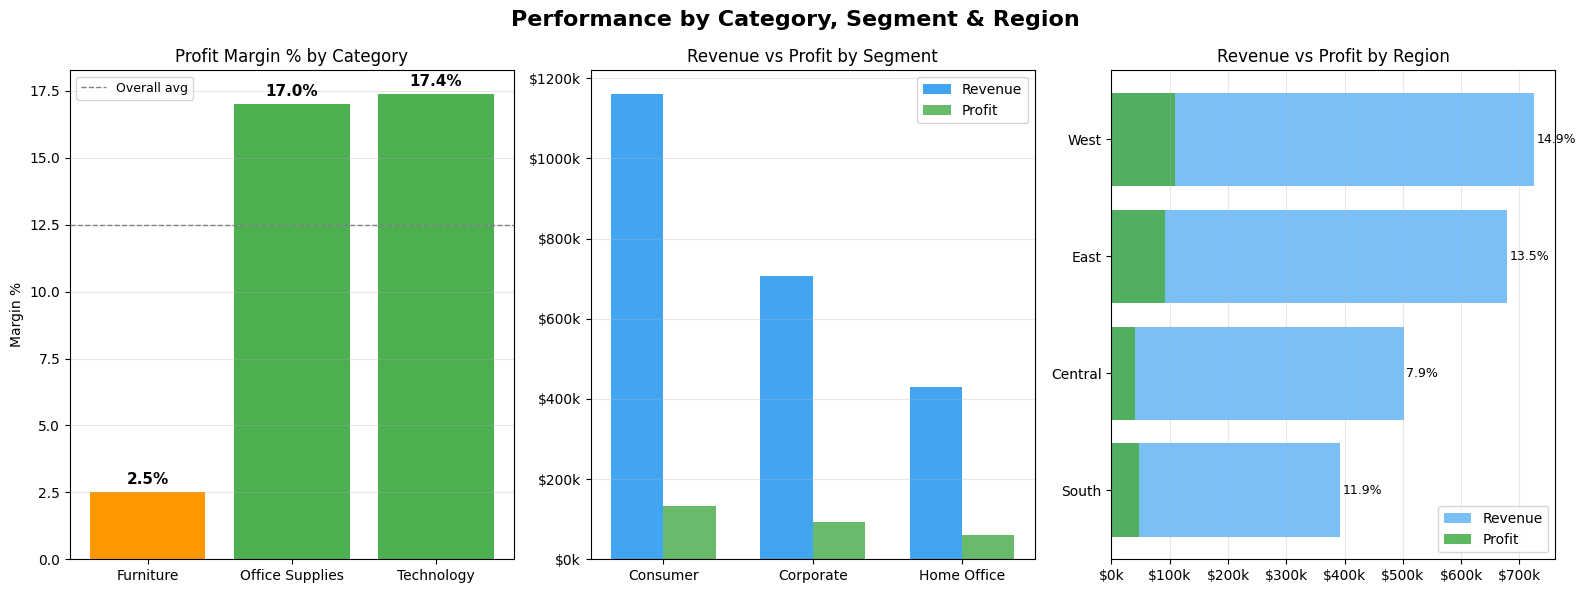

Saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Performance by Category, Segment & Region', fontsize=16, fontweight='bold')

# category profit margin
cat = df.groupby('Category')[['Sales','Profit']].sum().reset_index()
cat['Margin %'] = (cat['Profit'] / cat['Sales'] * 100).round(1)
colors = ['#4CAF50' if m > 10 else '#FF9800' if m > 0 else '#f44336' for m in cat['Margin %']]
bars = axes[0].bar(cat['Category'], cat['Margin %'], color=colors)
axes[0].set_title('Profit Margin % by Category')
axes[0].set_ylabel('Margin %')
axes[0].axhline(y=12.5, color='gray', linestyle='--', linewidth=1, label='Overall avg')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, cat['Margin %']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# segment revenue + profit side by side
seg = df.groupby('Segment')[['Sales','Profit']].sum().reset_index()
x = range(len(seg))
w = 0.35
axes[1].bar([i - w/2 for i in x], seg['Sales'], w, label='Revenue', color='#2196F3', alpha=0.85)
axes[1].bar([i + w/2 for i in x], seg['Profit'], w, label='Profit', color='#4CAF50', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg['Segment'])
axes[1].set_title('Revenue vs Profit by Segment')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# region performance
reg = df.groupby('Region')[['Sales','Profit']].sum().reset_index()
reg['Margin %'] = (reg['Profit'] / reg['Sales'] * 100).round(1)
reg = reg.sort_values('Sales', ascending=True)
y = range(len(reg))
axes[2].barh(y, reg['Sales'], color='#2196F3', alpha=0.6, label='Revenue')
axes[2].barh(y, reg['Profit'], color='#4CAF50', alpha=0.9, label='Profit')
axes[2].set_yticks(y)
axes[2].set_yticklabels(reg['Region'])
axes[2].set_title('Revenue vs Profit by Region')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for i, (_, row) in enumerate(reg.iterrows()):
    axes[2].text(row['Sales'] + 5000, i, f"{row['Margin %']}%", va='center', fontsize=9)
axes[2].legend()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/02_category_segment_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

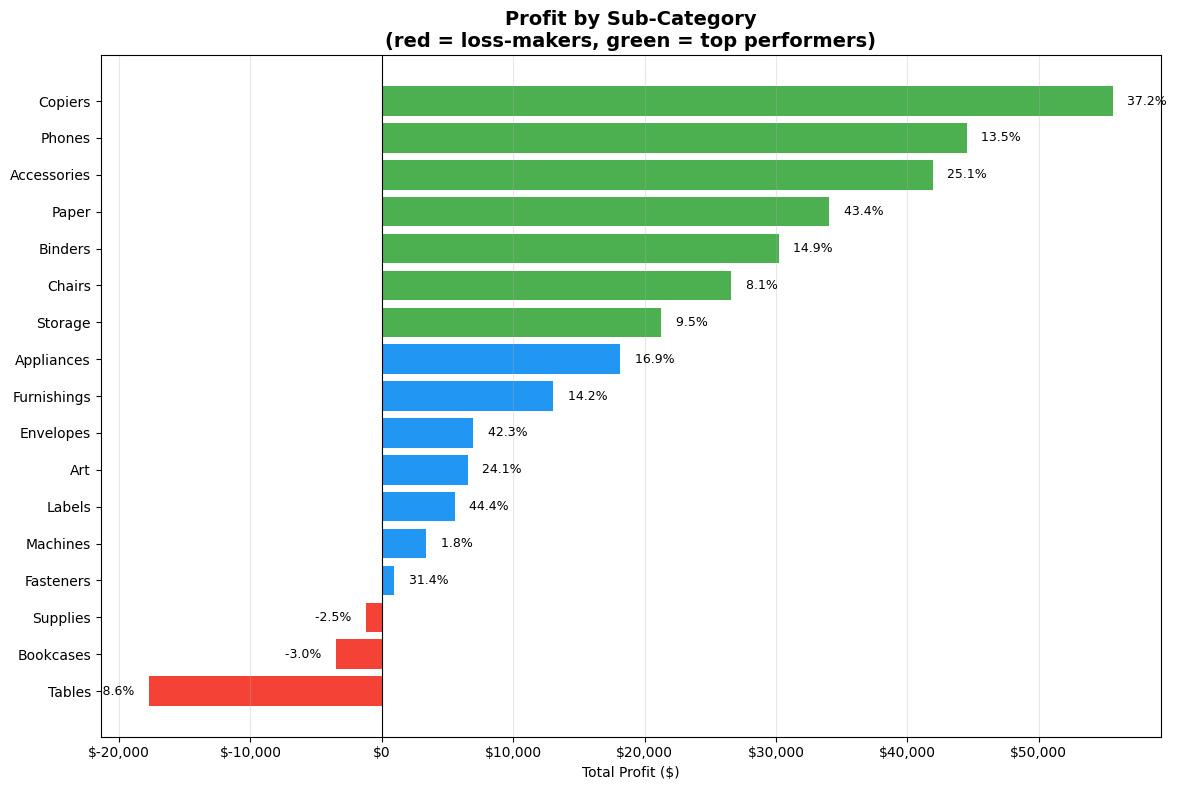

Saved.


In [10]:
sub = df.groupby('Sub-Category')[['Sales','Profit']].sum().reset_index()
sub['Margin %'] = (sub['Profit'] / sub['Sales'] * 100).round(1)
sub = sub.sort_values('Profit', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#f44336' if p < 0 else '#4CAF50' if p > 20000 else '#2196F3' for p in sub['Profit']]
bars = ax.barh(sub['Sub-Category'], sub['Profit'], color=colors)
ax.set_title('Profit by Sub-Category\n(red = loss-makers, green = top performers)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axvline(x=0, color='black', linewidth=0.8)
for bar, (_, row) in zip(bars, sub.iterrows()):
    x_pos = row['Profit'] + (500 if row['Profit'] >= 0 else -500)
    ha = 'left' if row['Profit'] >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f"  {row['Margin %']}%  ", va='center', ha=ha, fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/03_subcategory_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

=== DISCOUNT IMPACT TABLE ===
Discount Band  Orders  Avg_Profit_Margin  Loss_Rate %  Total_Profit
  No Discount    4798              34.00         0.00     320987.60
        1-10%      94              15.60         4.30       9029.18
       11-20%    3709              17.50        14.00      91756.30
       21-30%     227             -11.50        91.60     -10369.28
       31-50%     310             -29.60        91.60     -48447.73
         51%+     856            -113.90       100.00     -76559.05


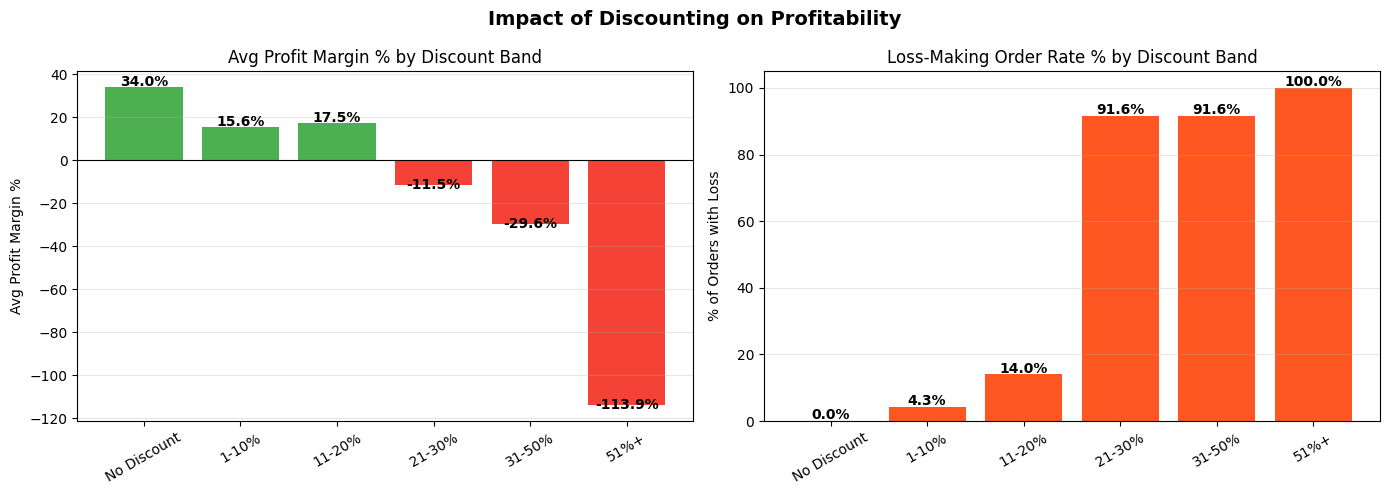

Saved.


In [11]:
# bin discounts into groups
df['Discount Band'] = pd.cut(df['Discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=['No Discount', '1-10%', '11-20%', '21-30%', '31-50%', '51%+'])

discount = df.groupby('Discount Band', observed=True).agg(
    Orders=('Order ID', 'count'),
    Avg_Profit_Margin=('Profit Margin %', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Loss_Rate=('Is Loss', 'mean')
).reset_index()
discount['Loss_Rate %'] = (discount['Loss_Rate'] * 100).round(1)
discount['Avg_Profit_Margin'] = discount['Avg_Profit_Margin'].round(1)

print("=== DISCOUNT IMPACT TABLE ===")
print(discount[['Discount Band','Orders','Avg_Profit_Margin','Loss_Rate %','Total_Profit']].to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impact of Discounting on Profitability', fontsize=14, fontweight='bold')

colors = ['#4CAF50' if m > 0 else '#f44336' for m in discount['Avg_Profit_Margin']]
bars = ax1.bar(discount['Discount Band'], discount['Avg_Profit_Margin'], color=colors)
ax1.set_title('Avg Profit Margin % by Discount Band')
ax1.set_ylabel('Avg Profit Margin %')
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, discount['Avg_Profit_Margin']):
    y = bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 2
    ax1.text(bar.get_x() + bar.get_width()/2, y, f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2.bar(discount['Discount Band'], discount['Loss_Rate %'], color='#FF5722')
ax2.set_title('Loss-Making Order Rate % by Discount Band')
ax2.set_ylabel('% of Orders with Loss')
ax2.tick_params(axis='x', rotation=30)
for bar, val in zip(ax2.patches, discount['Loss_Rate %']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/04_discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [12]:
yoy = df.groupby('Order Year').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Customers=('Customer ID', 'nunique'),
    Avg_Margin=('Profit Margin %', 'mean')
).reset_index()

yoy['Revenue Growth %'] = yoy['Revenue'].pct_change().mul(100).round(1)
yoy['Profit Growth %'] = yoy['Profit'].pct_change().mul(100).round(1)
yoy['Margin %'] = (yoy['Profit'] / yoy['Revenue'] * 100).round(1)
yoy['Revenue'] = yoy['Revenue'].round(0)
yoy['Profit'] = yoy['Profit'].round(0)

print("=== YEAR OVER YEAR GROWTH ===")
print(yoy[['Order Year','Revenue','Revenue Growth %','Profit',
           'Profit Growth %','Margin %','Orders','Customers']].to_string(index=False))

=== YEAR OVER YEAR GROWTH ===
 Order Year   Revenue  Revenue Growth %   Profit  Profit Growth %  Margin %  Orders  Customers
       2014 484247.00               NaN 49544.00              NaN     10.20     969        595
       2015 470533.00             -2.80 61619.00            24.40     13.10    1038        573
       2016 609206.00             29.50 81795.00            32.70     13.40    1315        638
       2017 733215.00             20.40 93439.00            14.20     12.70    1687        693


In [13]:
import os

# main clean export
df.to_csv('../data/clean/superstore_clean.csv', index=False)

# aggregated exports
df.groupby(['Year-Month','Category','Region','Segment']).agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','count'),
    Avg_Discount=('Discount','mean'),
    Avg_Days_to_Ship=('Days to Ship','mean')
).reset_index().to_csv('../outputs/monthly_summary.csv', index=False)

df.groupby(['State','Region']).agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','count'),
    Margin=('Profit Margin %','mean')
).reset_index().to_csv('../outputs/state_summary.csv', index=False)

df.groupby(['Category','Sub-Category']).agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','count'),
    Avg_Discount=('Discount','mean'),
    Margin=('Profit Margin %','mean'),
    Loss_Rate=('Is Loss','mean')
).reset_index().to_csv('../outputs/subcategory_summary.csv', index=False)

print("Exported files:")
for f in os.listdir('../outputs'):
    size = os.path.getsize(f'../outputs/{f}')
    print(f"  {f} — {size/1024:.1f} KB")

Exported files:
  01_revenue_profit_trend.png — 125.6 KB
  02_category_segment_region.png — 92.0 KB
  03_subcategory_profit.png — 82.4 KB
  04_discount_impact.png — 84.1 KB
  monthly_summary.csv — 119.9 KB
  state_summary.csv — 2.8 KB
  subcategory_summary.csv — 1.8 KB
